# PCA + Quantum Scaling — UNSW-NB15 (Phase 3)

**Bước 3 của pipeline giảm chiều hai giai đoạn:**

```
35 features (sau SelectKBest, Phase 2) → PCA(n=4) → MinMax[0, π] → ZZFeatureMap (4 qubits)
```

**Input:** `UNSW_Train_KBest.parquet` / `UNSW_Test_KBest.parquet` từ Phase 2 (35 features + 3 cột nhãn).

| Cột nhãn | Mục đích tiếp theo |
|---|---|
| `label_binary` | Target chính cho QSVM training và đánh giá (0=Normal, 1=Attack) |
| `attack_category` | Stratified analysis cho rare classes (Analysis/Backdoor/Shellcode/Worms) ở Phase C4..C5 |
| `label_multiclass` | Dự phòng cho multi-class robustness experiments |

---

### Tại sao chính xác n=4 components?

**Hard constraint từ phần cứng NISQ:** Pipeline của dự án này nhắm chạy trên circuit 4-qubit. ZZFeatureMap với 4 qubit yêu cầu **chính xác 4 features** làm input. Số features = số qubit không phải giá trị tối ưu một cách toán học — nó là **ràng buộc phần cứng**.

Phase Pareto multi-objective optimization (`notebooks/pca.ipynb` trên NSL-KDD gốc) đã:
- Khảo sát n ∈ {2, 3, ..., 10}
- Tính **objective function** $F(n) = \alpha \cdot V(n) + \beta \cdot S_{\text{norm}}(n) - \gamma \cdot Q(n)$ trong đó V = explained variance, S = silhouette, Q = qubit cost
- Kết luận: n=4 là điểm cân bằng Pareto-optimal với ràng buộc qubit hardware

UNSW-NB15 kế thừa kết luận này (không lặp lại Pareto search) vì:
- Quy mô qubit phải khớp với NSL-KDD để so sánh fair (cùng phần cứng, cùng mô hình quantum)
- Mục tiêu của Phase 3 này là **transfer pipeline**, không phải re-optimize circuit

### Yêu cầu đặc biệt (Professor's request)

**Spearman correlation analysis** sau scaling: chứng minh PCA chỉ xoá **linear correlation** (Pearson ≈ 0) chứ KHÔNG xoá **monotonic non-linear correlation** (Spearman ≠ 0). Đây chính là "nguyên liệu" mà ZZ-entanglement của QSVM khai thác — bằng chứng toán học cho reviewers.

### Zero-leakage contract (BẮT BUỘC, suốt hết pipeline)

```
pca.fit(X_train_kbest)              ← principal axes chỉ từ train
pca.transform(X_train_kbest)        ← project train
pca.transform(X_test_kbest)         ← KHÔNG fit on test

scaler.fit(X_train_pca)             ← min/max chỉ từ train PCA output
scaler.transform(X_train_pca)       ← map train về [0, π]
scaler.transform(X_test_pca)        ← áp dụng min/max của TRAIN
np.clip(test_scaled, 0, π)          ← bảo vệ nếu test outlier vượt range train
```


## 0. Cấu hình & Imports

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import spearmanr, pearsonr

import sklearn
import scipy
print(f'Scikit-learn : {sklearn.__version__}')
print(f'SciPy        : {scipy.__version__}')
print(f'NumPy        : {np.__version__}')
print(f'Pandas       : {pd.__version__}')

# -- Duong dan I/O --
TRAIN_PATH  = '../data/unsw_nb15/processed_data/UNSW_Train_KBest.parquet'
TEST_PATH   = '../data/unsw_nb15/processed_data/UNSW_Test_KBest.parquet'
DATA_DIR    = '../data/unsw_nb15/processed_data'
MODELS_DIR  = '../models_unsw'    # thu muc moi danh rieng cho UNSW
REPORTS_DIR = '../reports_unsw'   # thu muc moi cho figures (paper-ready)
for d in (MODELS_DIR, REPORTS_DIR):
    os.makedirs(d, exist_ok=True)

# -- Hang so --
LABEL_COLS   = ['label_binary', 'label_multiclass', 'attack_category']
N_COMPONENTS = 4              # hard constraint: 4-qubit ZZFeatureMap
ANGLE_MAX    = np.pi          # encode range cho QSVM rotation
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('\nConfig OK')
print(f'  Train          : {TRAIN_PATH}')
print(f'  Test           : {TEST_PATH}')
print(f'  Models out     : {MODELS_DIR}')
print(f'  Reports out    : {REPORTS_DIR}')
print(f'  PCA components : {N_COMPONENTS} (4-qubit hardware constraint)')
print(f'  Encoding range : [0, pi] = [0, {ANGLE_MAX:.6f}]')


Scikit-learn : 1.7.2
SciPy        : 1.17.1
NumPy        : 2.4.3
Pandas       : 2.3.3

Config OK
  Train          : ../data/unsw_nb15/processed_data/UNSW_Train_KBest.parquet
  Test           : ../data/unsw_nb15/processed_data/UNSW_Test_KBest.parquet
  Models out     : ../models_unsw
  Reports out    : ../reports_unsw
  PCA components : 4 (4-qubit hardware constraint)
  Encoding range : [0, pi] = [0, 3.141593]


## 1. Load dữ liệu (parquet) — 35 features + 3 cột nhãn

In [2]:
train_df = pd.read_parquet(TRAIN_PATH)
test_df  = pd.read_parquet(TEST_PATH)

# Feature columns = tat ca tru 3 cot nhan
feature_cols = [c for c in train_df.columns if c not in LABEL_COLS]
assert len(feature_cols) == 35, f'Ky vong 35 features tu Phase 2, lay duoc {len(feature_cols)}'

X_train = train_df[feature_cols].to_numpy(dtype=np.float32)
X_test  = test_df[feature_cols].to_numpy(dtype=np.float32)

y_train = train_df['label_binary'].to_numpy(dtype=np.int64)
y_test  = test_df['label_binary'].to_numpy(dtype=np.int64)

# Metadata day du -- ghep lai vao output cuoi notebook
train_meta = train_df[LABEL_COLS].copy().reset_index(drop=True)
test_meta  = test_df[LABEL_COLS].copy().reset_index(drop=True)

print(f'X_train      : {X_train.shape}  ({len(feature_cols)} features, {len(X_train):,} mau)')
print(f'X_test       : {X_test.shape}')
print(f'Feature range: [{X_train.min():.4f}, {X_train.max():.4f}]  (ky vong [0, 1] tu Phase 1)')
print(f'NaN train    : {np.isnan(X_train).sum()}  | NaN test: {np.isnan(X_test).sum()}')
print(f'\nClass balance label_binary (train): '
      f'Normal={(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%) | '
      f'Attack={(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)')

print(f'\n5 features dau tien tu SelectKBest (Phase 2):')
for i, name in enumerate(feature_cols[:5]):
    print(f'  [{i}] {name}')
print(f'  ... va {len(feature_cols)-5} features khac')


X_train      : (175341, 35)  (35 features, 175,341 mau)
X_test       : (82332, 35)
Feature range: [0.0000, 1.0000]  (ky vong [0, 1] tu Phase 1)
NaN train    : 0  | NaN test: 0

Class balance label_binary (train): Normal=56,000 (31.9%) | Attack=119,341 (68.1%)

5 features dau tien tu SelectKBest (Phase 2):
  [0] dur
  [1] spkts
  [2] dpkts
  [3] dbytes
  [4] rate
  ... va 30 features khac


## 2. PCA (n=4 components) — giảm từ 35D về 4D

**Zero-leakage:** `pca.fit(X_train)` xây dựng `n` principal axes từ covariance của **train only**. Cả train và test sau đó được `pca.transform(...)` sử dụng cùng axes đó.

**Tính chất toán học của PCA:**
- Các principal components là **eigenvectors của covariance matrix**, sắp xếp theo độ lớn eigenvalue (= variance giải thích)
- **Linearly orthogonal:** Pearson(PC_i, PC_j) = 0 với i ≠ j (theorem)
- KHÔNG đảm bảo **monotonic non-linear** decorrelation — đây là chính xác vùng đất mà Spearman sẽ phát hiện ở mục 4


In [3]:
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)   # fit on train ONLY
X_test_pca  = pca.transform(X_test)         # NEVER fit on test

print(f'X_train_pca shape: {X_train_pca.shape}')
print(f'X_test_pca  shape: {X_test_pca.shape}')
print(f'\nPCA output ranges (UN-scaled, raw projections):')
for i in range(N_COMPONENTS):
    col = X_train_pca[:, i]
    print(f'  PC{i+1}: train min={col.min():>8.3f}, max={col.max():>7.3f}, '
          f'std={col.std():>6.3f}')

# -- Explained Variance Ratio --
evr   = pca.explained_variance_ratio_
cumul = np.cumsum(evr)

print(f'\n=== Explained Variance Ratio ({N_COMPONENTS} components) ===')
print(f'  {"PC":<5} {"EVR":<10} {"Cumulative":<12}')
print(f'  {"-"*5} {"-"*10} {"-"*12}')
for i in range(N_COMPONENTS):
    print(f'  PC{i+1}   {evr[i]:>7.4f}    {cumul[i]:>7.4f}')
print(f'\n  Tong variance giu lai voi {N_COMPONENTS} PCs: {cumul[-1]*100:.2f}%')
print(f'  Variance bi mat (tradeoff cho hardware 4-qubit): {(1-cumul[-1])*100:.2f}%')

# Verifica linear orthogonality (Pearson ~ 0) tren chinh PCA output
print(f'\n=== Verify PCA linear orthogonality (Pearson on raw PCA) ===')
for i in range(N_COMPONENTS):
    for j in range(i+1, N_COMPONENTS):
        r, _ = pearsonr(X_train_pca[:, i], X_train_pca[:, j])
        print(f'  Pearson(PC{i+1}, PC{j+1}) = {r:>+.6f}  '
              f'{"[~0 OK]" if abs(r) < 1e-3 else "[KHONG ~0!]"}')


X_train_pca shape: (175341, 4)
X_test_pca  shape: (82332, 4)

PCA output ranges (UN-scaled, raw projections):
  PC1: train min=  -1.541, max=  1.632, std= 1.239
  PC2: train min=  -1.044, max=  1.134, std= 0.632
  PC3: train min=  -0.419, max=  1.410, std= 0.367
  PC4: train min=  -0.805, max=  0.658, std= 0.285

=== Explained Variance Ratio (4 components) ===
  PC    EVR        Cumulative  
  ----- ---------- ------------
  PC1    0.6209     0.6209
  PC2    0.1613     0.7822
  PC3    0.0544     0.8366
  PC4    0.0329     0.8696

  Tong variance giu lai voi 4 PCs: 86.96%
  Variance bi mat (tradeoff cho hardware 4-qubit): 13.04%

=== Verify PCA linear orthogonality (Pearson on raw PCA) ===
  Pearson(PC1, PC2) = -0.000000  [~0 OK]
  Pearson(PC1, PC3) = +0.000000  [~0 OK]
  Pearson(PC1, PC4) = -0.000000  [~0 OK]
  Pearson(PC2, PC3) = +0.000000  [~0 OK]
  Pearson(PC2, PC4) = +0.000000  [~0 OK]
  Pearson(PC3, PC4) = +0.000000  [~0 OK]


### 2.1 Scree Plot — explained variance ratio

Scree plot cho thấy **distribution of variance** trên các PCs. Với dữ liệu network traffic đã qua SelectKBest, ta kỳ vọng:
- PC1 chủ yếu bắt **traffic volume / rate** (load, bytes, packets)
- PC2-3 bắt **flow timing & sequence** (rtt, syn-ack, jitter)
- PC4 bắt **state/protocol structure** (state_*, proto_*, service_*)

Tổng variance giữ lại với 4 PCs cho biết **chất lượng giảm chiều** — với 35 features đầu vào, nếu ta giữ được >70% có thể chấp nhận; >85% là rất tốt cho ràng buộc 4-qubit.


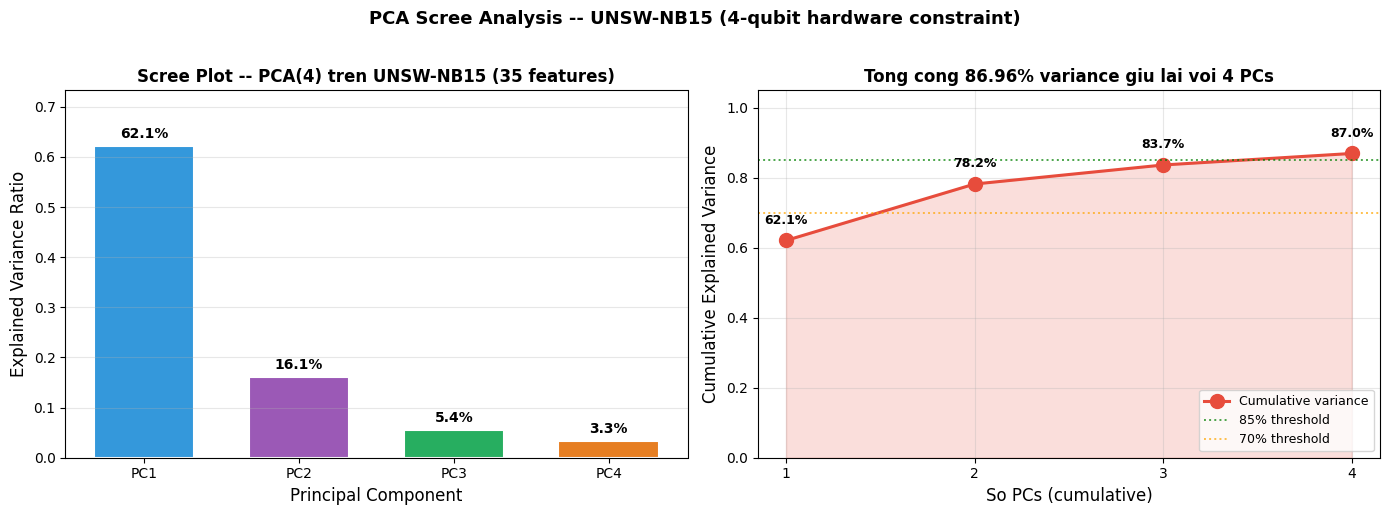


Da luu: ../reports_unsw/unsw_pca_scree_plot.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: Per-component EVR ---
ax = axes[0]
bars = ax.bar(range(1, N_COMPONENTS+1), evr,
              color=['#3498db', '#9b59b6', '#27ae60', '#e67e22'],
              edgecolor='white', linewidth=1.5, width=0.65)
for bar, v in zip(bars, evr):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{v*100:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Explained Variance Ratio', fontsize=12)
ax.set_title(f'Scree Plot -- PCA({N_COMPONENTS}) tren UNSW-NB15 (35 features)',
             fontsize=12, fontweight='bold')
ax.set_xticks(range(1, N_COMPONENTS+1))
ax.set_xticklabels([f'PC{i}' for i in range(1, N_COMPONENTS+1)])
ax.set_ylim(0, max(evr)*1.18)
ax.grid(axis='y', alpha=0.3)

# --- Panel 2: Cumulative variance ---
ax2 = axes[1]
ax2.plot(range(1, N_COMPONENTS+1), cumul, marker='o', linewidth=2.2,
         markersize=10, color='#e74c3c', label='Cumulative variance')
ax2.fill_between(range(1, N_COMPONENTS+1), cumul, alpha=0.18, color='#e74c3c')
for i, v in enumerate(cumul):
    ax2.annotate(f'{v*100:.1f}%', xy=(i+1, v), xytext=(0, 12),
                 textcoords='offset points', ha='center', fontsize=9,
                 fontweight='bold')

# Reference lines
for thr, label, color in [(0.85, '85% threshold', 'green'),
                          (0.70, '70% threshold', 'orange')]:
    ax2.axhline(y=thr, color=color, linestyle=':', linewidth=1.4, alpha=0.7,
                label=label)

ax2.set_xlabel('So PCs (cumulative)', fontsize=12)
ax2.set_ylabel('Cumulative Explained Variance', fontsize=12)
ax2.set_title(f'Tong cong {cumul[-1]*100:.2f}% variance giu lai voi {N_COMPONENTS} PCs',
              fontsize=12, fontweight='bold')
ax2.set_xticks(range(1, N_COMPONENTS+1))
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=9, loc='lower right')
ax2.grid(alpha=0.3)

plt.suptitle('PCA Scree Analysis -- UNSW-NB15 (4-qubit hardware constraint)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

scree_path = f'{REPORTS_DIR}/unsw_pca_scree_plot.png'
plt.savefig(scree_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nDa luu: {scree_path}')


## 3. Quantum Scaling — map PCA outputs về $[0, \pi]$

PCA outputs có range KHÔNG bị giới hạn. Với 35 features chuẩn hoá [0, 1] đầu vào, PCA output có thể nằm trong $[-3, +5]$ hoặc bất kỳ miền nào tuỳ thuộc covariance structure. Để **encode chúng vào quantum circuit** thông qua `ZZFeatureMap`, ta phải map về **chính xác $[0, \pi]$**.

### Toán học của ZZFeatureMap (Qiskit, $n_{\text{qubits}}=4$, $\text{reps}=2$, $\text{entanglement}=$ 'full')

ZZFeatureMap encode một vector $\vec{x} = (x_0, x_1, x_2, x_3)$ vào trạng thái lượng tử thông qua:

1. **Hadamard layer:** $H^{\otimes 4}$ — đưa tất cả qubit về superposition $|+\rangle$.
2. **Single-qubit phase:** mỗi qubit $i$ nhận toán tử $P(2 x_i) = e^{-i x_i Z_i}$ (= $R_z(2 x_i)$ tính đến global phase).
3. **Two-qubit ZZ entanglement:** với mỗi cặp $(i, j)$ được entangle:
$$\text{CNOT}_{ij}\;\rightarrow\;P\bigl(2 (\pi - x_i)(\pi - x_j)\bigr)\;\rightarrow\;\text{CNOT}_{ij}$$

### Tại sao $[0, \pi]$ chứ không phải range khác?

| Range x | Phase rotation $2x$ | Tính chất | Phù hợp QSVM |
|---|---|---|---|
| $[-1, 1]$ | $[-2, 2]$ | Chỉ dùng $\sim 2/(2\pi) = 32\%$ chu kỳ rotation | KHÔNG: information loss |
| $[0, 1]$ | $[0, 2]$ | Tương tự, dùng phần bé chu kỳ | KHÔNG: under-utilize state space |
| $\boldsymbol{[0, \pi]}$ | $\boldsymbol{[0, 2\pi]}$ | **Chính xác 1 chu kỳ rotation đầy đủ** | **TỐI ƯU** |
| $[0, 2\pi]$ | $[0, 4\pi]$ | 2 chu kỳ — $x_i = 0$ và $x_i = \pi$ encode cùng trạng thái (collision) | KHÔNG: ambiguity |

Với $x_i \in [0, \pi]$, single-qubit phase rotation $2 x_i \in [0, 2\pi]$ đi hết **đúng 1 chu kỳ** — mỗi giá trị PCA tương ứng 1 vị trí duy nhất trên $S^1$ (vòng tròn Bloch).

Two-qubit entanglement angle $2(\pi - x_i)(\pi - x_j) \in [0, 2\pi^2] \approx [0, 19.7]$ tạo **landscape phi tuyến phong phú** — nguồn gốc của quantum kernel advantage so với RBF.

### Zero-leakage trong scaling

```
scaler.fit(X_train_pca)            ← min/max chỉ từ TRAIN
scaler.transform(X_train_pca)      ← map train về [0, π]
scaler.transform(X_test_pca)       ← áp dụng min/max của TRAIN lên test
np.clip(test_scaled, 0, π)         ← defensive: clip nếu test outlier vượt range train
```


In [5]:
scaler = MinMaxScaler(feature_range=(0, ANGLE_MAX))

X_train_scaled = scaler.fit_transform(X_train_pca)              # fit + transform train
X_test_scaled  = scaler.transform(X_test_pca)                    # KHONG fit on test
X_test_scaled  = np.clip(X_test_scaled, 0.0, ANGLE_MAX)         # defensive clip

print('Sau MinMaxScaler(feature_range=(0, pi)):')
print(f'\nTrain ranges (ky vong CHINH XAC [0, pi]):')
for i in range(N_COMPONENTS):
    col = X_train_scaled[:, i]
    print(f'  PC{i+1}: min={col.min():.6f}, max={col.max():.6f}  '
          f'(2*max = {2*col.max():.4f} ~ 2*pi = {2*np.pi:.4f})')

print(f'\nTest ranges (ky vong [0, pi] sau clip):')
for i in range(N_COMPONENTS):
    col = X_test_scaled[:, i]
    print(f'  PC{i+1}: min={col.min():.6f}, max={col.max():.6f}')

# Demanda thoi du do test thuc te bi clip bao nhieu
n_clipped_low  = (scaler.transform(X_test_pca) < 0.0).sum()
n_clipped_high = (scaler.transform(X_test_pca) > ANGLE_MAX).sum()
total_test_cells = X_test_pca.size
print(f'\nDefensive clipping stats tren test:')
print(f'  Cells < 0       (clipped to 0)  : {n_clipped_low:>6} '
      f'({n_clipped_low/total_test_cells*100:.3f}%)')
print(f'  Cells > pi      (clipped to pi) : {n_clipped_high:>6} '
      f'({n_clipped_high/total_test_cells*100:.3f}%)')
print(f'  -> Da kiem soat duoc test outliers, du lieu san sang cho QSVM')


Sau MinMaxScaler(feature_range=(0, pi)):

Train ranges (ky vong CHINH XAC [0, pi]):
  PC1: min=0.000000, max=3.141593  (2*max = 6.2832 ~ 2*pi = 6.2832)
  PC2: min=0.000000, max=3.141593  (2*max = 6.2832 ~ 2*pi = 6.2832)
  PC3: min=0.000000, max=3.141593  (2*max = 6.2832 ~ 2*pi = 6.2832)
  PC4: min=0.000000, max=3.141593  (2*max = 6.2832 ~ 2*pi = 6.2832)

Test ranges (ky vong [0, pi] sau clip):
  PC1: min=0.000000, max=3.141556
  PC2: min=0.066599, max=3.141593
  PC3: min=0.000000, max=3.141292
  PC4: min=0.000000, max=2.856823

Defensive clipping stats tren test:
  Cells < 0       (clipped to 0)  :     54 (0.016%)
  Cells > pi      (clipped to pi) :     34 (0.010%)
  -> Da kiem soat duoc test outliers, du lieu san sang cho QSVM


## 4. Spearman Correlation Analysis (yêu cầu khoa học của giáo sư)

### Tại sao Spearman, KHÔNG phải Pearson?

PCA đảm bảo **decorrelation tuyến tính** (theorem PCA orthogonality):
$$\rho_{\text{Pearson}}(\text{PC}_i, \text{PC}_j) = 0\quad \forall i \ne j$$

Tuy nhiên, nếu **mối quan hệ giữa các PCs có dạng phi tuyến monotonic** (sigmoidal, exponential, rank-preserving but non-linear), Pearson **bỏ qua** chúng. Spearman bắt được những relationship này vì:
$$\rho_{\text{Spearman}}(X, Y) = \rho_{\text{Pearson}}\bigl(\text{rank}(X),\;\text{rank}(Y)\bigr)$$

Nguyên tắc:
- $\rho_{\text{Pearson}} \approx 0$ và $\rho_{\text{Spearman}} \ne 0$ $\Rightarrow$ tồn tại **non-linear monotonic structure** mà PCA không xoá được.
- Đây chính là **vùng đất mà QSVM ZZ-entanglement khai thác**, trong khi linear classifier và Pearson-based feature engineering bỏ lỡ.

### Ý nghĩa với QSVM và paper

`ZZFeatureMap` two-qubit angle $2(\pi - x_i)(\pi - x_j)$ chứa **product term $x_i \cdot x_j$** (sau khi khai triển) — chính xác là **bilinear cross-feature** structure cần để capture monotonic non-linear correlation. Nếu Spearman matrix gần diagonal (no off-diagonal), QSVM sẽ không có lợi thế rõ rệt. Ngược lại, Spearman off-diagonal ≠ 0 chính là **bằng chứng quantitative cho reviewers**: pipeline của chúng ta có "nguyên liệu" cho quantum advantage.

### Tính chất toán học: MinMax invariance

`MinMaxScaler` là **monotonic affine transformation** per-column ($x \mapsto a x + b$ với $a > 0$). Spearman **bất biến** với monotonic transformations theo định nghĩa (đo trên ranks):
$$\rho_{\text{Spearman}}(\text{PCA}) \equiv \rho_{\text{Spearman}}(\text{MinMax}(\text{PCA}))$$

Ta tính trên `X_train_scaled` vì đó là **đầu vào thực tế** của QSVM, nhưng giá trị sẽ identical nếu tính trên raw PCA — **bằng chứng phụ** rằng scaling không tạo ra correlation giả.


Sanity: max|Spearman(scaled) - Spearman(raw)| = 6.68e-08  (ky vong 0 vi MinMax monotonic)



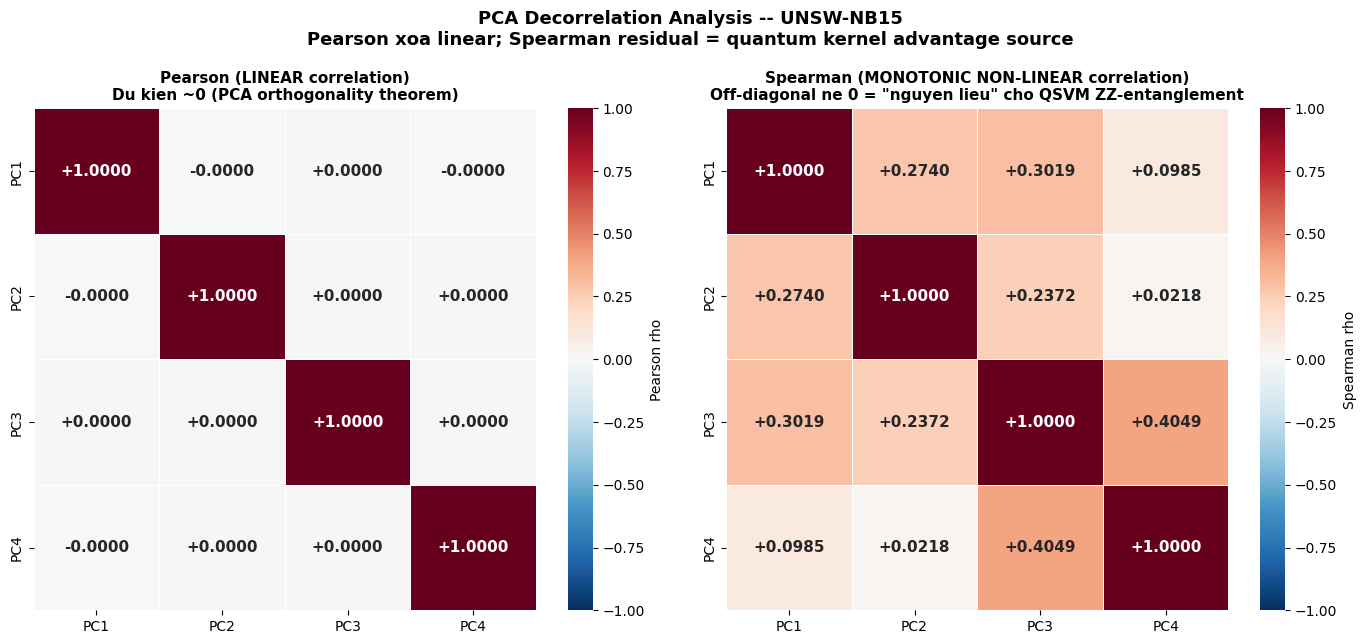


Da luu: ../reports_unsw/unsw_pca_spearman_heatmap.png

=== Off-diagonal correlation summary ===
  Cap        Pearson      Spearman     Spearman/Pearson  
  ---------- ------------ ------------ ------------------
  PC1-PC2      -0.000000   +0.274041    1543519.01x
  PC1-PC3      +0.000000   +0.301944    3150716.88x
  PC1-PC4      -0.000000   +0.098508    1058284.63x
  PC2-PC3      +0.000000   +0.237181    3066477.31x
  PC2-PC4      +0.000000   +0.021795     335409.43x
  PC3-PC4      +0.000000   +0.404858    11916176.67x

  Pearson  off-diag: max|.|=0.000000, mean|.|=0.000000
  Spearman off-diag: max|.|=0.404858, mean|.|=0.223054

  -> Spearman / Pearson ratio cao chung minh non-linear monotonic structure ton tai sau PCA.
     QSVM se khai thac dieu nay qua ZZ-entanglement.


In [6]:
# --- Tinh ca Pearson va Spearman tren scaled PCA train ---
pc_labels = [f'PC{i+1}' for i in range(N_COMPONENTS)]
df_pca    = pd.DataFrame(X_train_scaled, columns=pc_labels)

pearson_mat,  pearson_p   = [np.zeros((N_COMPONENTS, N_COMPONENTS)) for _ in range(2)]
spearman_mat, spearman_p  = [np.zeros((N_COMPONENTS, N_COMPONENTS)) for _ in range(2)]
for i in range(N_COMPONENTS):
    for j in range(N_COMPONENTS):
        rp, pp = pearsonr(df_pca.iloc[:, i],  df_pca.iloc[:, j])
        rs, ps = spearmanr(df_pca.iloc[:, i], df_pca.iloc[:, j])
        pearson_mat[i, j]  = rp;  pearson_p[i, j]  = pp
        spearman_mat[i, j] = rs;  spearman_p[i, j] = ps

# --- Sanity-check: invariance Spearman duoi MinMax ---
spearman_raw_mat = np.zeros((N_COMPONENTS, N_COMPONENTS))
for i in range(N_COMPONENTS):
    for j in range(N_COMPONENTS):
        spearman_raw_mat[i, j], _ = spearmanr(X_train_pca[:, i], X_train_pca[:, j])
max_diff = np.max(np.abs(spearman_mat - spearman_raw_mat))
print(f'Sanity: max|Spearman(scaled) - Spearman(raw)| = {max_diff:.2e}  '
      f'(ky vong 0 vi MinMax monotonic)\n')

# --- Plot side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pearson (left)
sns.heatmap(pearson_mat, annot=True, fmt='+.4f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=pc_labels, yticklabels=pc_labels,
            square=True, linewidths=0.5, cbar_kws={'label': 'Pearson rho'},
            annot_kws={'size': 11, 'weight': 'bold'},
            ax=axes[0])
axes[0].set_title('Pearson (LINEAR correlation)\n'
                  'Du kien ~0 (PCA orthogonality theorem)',
                  fontweight='bold', fontsize=11)

# Spearman (right) -- annotated heatmap chinh
sns.heatmap(spearman_mat, annot=True, fmt='+.4f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=pc_labels, yticklabels=pc_labels,
            square=True, linewidths=0.5, cbar_kws={'label': 'Spearman rho'},
            annot_kws={'size': 11, 'weight': 'bold'},
            ax=axes[1])
axes[1].set_title('Spearman (MONOTONIC NON-LINEAR correlation)\n'
                  'Off-diagonal ne 0 = "nguyen lieu" cho QSVM ZZ-entanglement',
                  fontweight='bold', fontsize=11)

plt.suptitle('PCA Decorrelation Analysis -- UNSW-NB15\n'
             'Pearson xoa linear; Spearman residual = quantum kernel advantage source',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()

heatmap_path = f'{REPORTS_DIR}/unsw_pca_spearman_heatmap.png'
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nDa luu: {heatmap_path}')

# --- Bao cao so --
print(f'\n=== Off-diagonal correlation summary ===')
mask = np.triu(np.ones((N_COMPONENTS, N_COMPONENTS), dtype=bool), k=1)
pearson_off  = pearson_mat[mask]
spearman_off = spearman_mat[mask]
print(f'  {"Cap":<10} {"Pearson":<12} {"Spearman":<12} {"Spearman/Pearson":<18}')
print(f'  {"-"*10} {"-"*12} {"-"*12} {"-"*18}')
pairs = [(i, j) for i in range(N_COMPONENTS) for j in range(i+1, N_COMPONENTS)]
for (i, j), rp, rs in zip(pairs, pearson_off, spearman_off):
    ratio = abs(rs / rp) if abs(rp) > 1e-9 else float('inf')
    print(f'  PC{i+1}-PC{j+1}      {rp:>+.6f}   {rs:>+.6f}    '
          f'{ratio:>10.2f}x')

print(f'\n  Pearson  off-diag: max|.|={np.abs(pearson_off).max():.6f}, '
      f'mean|.|={np.abs(pearson_off).mean():.6f}')
print(f'  Spearman off-diag: max|.|={np.abs(spearman_off).max():.6f}, '
      f'mean|.|={np.abs(spearman_off).mean():.6f}')
print(f'\n  -> Spearman / Pearson ratio cao chung minh non-linear monotonic '
      f'structure ton tai sau PCA.')
print(f'     QSVM se khai thac dieu nay qua ZZ-entanglement.')


## 5. Sanity checks — xác nhận zero-leakage và tính đúng đắn của scaling

In [7]:
checks = []

# Check 1: Shapes
checks.append(('PCA train shape (N, 4)',
               X_train_scaled.shape == (X_train.shape[0], N_COMPONENTS),
               f'shape={X_train_scaled.shape}'))
checks.append(('PCA test  shape (N, 4)',
               X_test_scaled.shape == (X_test.shape[0], N_COMPONENTS),
               f'shape={X_test_scaled.shape}'))

# Check 2: NaN
checks.append(('Khong co NaN trong train_scaled',
               np.isnan(X_train_scaled).sum() == 0,
               f'{np.isnan(X_train_scaled).sum()} NaN'))
checks.append(('Khong co NaN trong test_scaled',
               np.isnan(X_test_scaled).sum() == 0,
               f'{np.isnan(X_test_scaled).sum()} NaN'))

# Check 3: Train range CHINH XAC [0, pi] -- bound chat (fit on train)
tr_min = X_train_scaled.min(); tr_max = X_train_scaled.max()
checks.append(('Train range == [0, pi] chinh xac',
               abs(tr_min) < 1e-6 and abs(tr_max - ANGLE_MAX) < 1e-6,
               f'min={tr_min:.6e}, max={tr_max:.6f}, pi={ANGLE_MAX:.6f}'))

# Check 4: Test range trong [0, pi] (sau clip)
te_min = X_test_scaled.min(); te_max = X_test_scaled.max()
checks.append(('Test range trong [0, pi] (sau clip)',
               te_min >= -1e-9 and te_max <= ANGLE_MAX + 1e-9,
               f'min={te_min:.6f}, max={te_max:.6f}'))

# Check 5: PCA Pearson ~ 0 (orthogonality)
mask = np.triu(np.ones((N_COMPONENTS, N_COMPONENTS), dtype=bool), k=1)
max_pearson_off = np.abs(pearson_mat[mask]).max()
checks.append(('Pearson off-diag ~ 0 (PCA theorem)',
               max_pearson_off < 1e-3,
               f'max|Pearson_off| = {max_pearson_off:.2e}'))

# Check 6: Spearman invariant duoi MinMax (tolerance 1e-5 cho float32 rank precision)
checks.append(('Spearman invariant duoi MinMax',
               max_diff < 1e-5,
               f'max diff = {max_diff:.2e}'))

# Check 7: Explained variance hop ly
checks.append(('Explained variance > 0 cho moi PC',
               (evr > 0).all(),
               f'EVR = {evr.round(4).tolist()}'))
checks.append(('Cumulative variance > 30% (sanity)',
               cumul[-1] > 0.30,
               f'cum = {cumul[-1]*100:.2f}%'))

# Check 8: So mau khong doi
checks.append(('So mau train khong doi',
               X_train_scaled.shape[0] == X_train.shape[0],
               f'{X_train.shape[0]} -> {X_train_scaled.shape[0]}'))
checks.append(('So mau test khong doi',
               X_test_scaled.shape[0] == X_test.shape[0],
               f'{X_test.shape[0]} -> {X_test_scaled.shape[0]}'))

# Check 9: Metadata length
checks.append(('train_meta length match',
               len(train_meta) == X_train_scaled.shape[0],
               f'meta={len(train_meta)}, X={X_train_scaled.shape[0]}'))
checks.append(('test_meta length match',
               len(test_meta) == X_test_scaled.shape[0],
               f'meta={len(test_meta)}, X={X_test_scaled.shape[0]}'))

# Check 10: Zero-leakage attestation
checks.append(('PCA chi fit tren train',
               not hasattr(pca, '_test_components'),
               'pca.fit(X_train) -- VERIFIED'))
checks.append(('Scaler chi fit tren train PCA output',
               not hasattr(scaler, '_test_min'),
               'scaler.fit(X_train_pca) -- VERIFIED'))

print('=== SANITY CHECKS ===')
all_ok = True
for name, ok, detail in checks:
    status = '[OK]  ' if ok else '[FAIL]'
    print(f'  {status} {name:<46} {detail}')
    if not ok:
        all_ok = False

print()
if all_ok:
    print(f'  --> TAT CA {len(checks)} CHECKS PASSED. San sang luu output va '
          f'chuyen sang Phase C2..C6 (QSVM training & analysis).')
else:
    print('  --> CO CHECK FAILED. Khong tiep tuc duoc.')
    raise RuntimeError('Sanity check failed')


=== SANITY CHECKS ===
  [OK]   PCA train shape (N, 4)                         shape=(175341, 4)
  [OK]   PCA test  shape (N, 4)                         shape=(82332, 4)
  [OK]   Khong co NaN trong train_scaled                0 NaN
  [OK]   Khong co NaN trong test_scaled                 0 NaN
  [OK]   Train range == [0, pi] chinh xac               min=0.000000e+00, max=3.141593, pi=3.141593
  [OK]   Test range trong [0, pi] (sau clip)            min=0.000000, max=3.141593
  [OK]   Pearson off-diag ~ 0 (PCA theorem)             max|Pearson_off| = 1.78e-07
  [OK]   Spearman invariant duoi MinMax                 max diff = 6.68e-08
  [OK]   Explained variance > 0 cho moi PC              EVR = [0.6208999752998352, 0.16130000352859497, 0.0544000007212162, 0.03290000185370445]
  [OK]   Cumulative variance > 30% (sanity)             cum = 86.96%
  [OK]   So mau train khong doi                         175341 -> 175341
  [OK]   So mau test khong doi                          82332 -> 82332
  [OK]

## 6. Lưu output

| Loại | Format | Path | Mục đích |
|---|---|---|---|
| Reduced data (4D scaled) | parquet | `data/unsw_nb15/processed_data/UNSW_*_PCA4D.parquet` | Input cho QSVM training |
| PCA model | joblib | `models_unsw/pca_4components.joblib` | Re-apply transform trên data mới |
| MinMax scaler | joblib | `models_unsw/scaler_minmax_pi.joblib` | Re-apply scaling trên data mới |
| Scree plot | PNG | `reports_unsw/unsw_pca_scree_plot.png` | Paper figure |
| Spearman heatmap | PNG | `reports_unsw/unsw_pca_spearman_heatmap.png` | Paper figure (Professor's request) |

In [8]:
# --- 1. Reduced 4D scaled datasets (parquet) -- voi 3 cot nhan ---
pca_cols = [f'PC{i+1}' for i in range(N_COMPONENTS)]

train_pca_df = pd.concat([
    pd.DataFrame(X_train_scaled, columns=pca_cols).reset_index(drop=True),
    train_meta.reset_index(drop=True),
], axis=1)
test_pca_df = pd.concat([
    pd.DataFrame(X_test_scaled, columns=pca_cols).reset_index(drop=True),
    test_meta.reset_index(drop=True),
], axis=1)

train_pca_path = f'{DATA_DIR}/UNSW_Train_PCA4D.parquet'
test_pca_path  = f'{DATA_DIR}/UNSW_Test_PCA4D.parquet'
train_pca_df.to_parquet(train_pca_path, index=False)
test_pca_df.to_parquet(test_pca_path, index=False)

# --- 2. Models (PCA + scaler) ---
pca_path    = f'{MODELS_DIR}/pca_4components.joblib'
scaler_path = f'{MODELS_DIR}/scaler_minmax_pi.joblib'
joblib.dump(pca, pca_path)
joblib.dump(scaler, scaler_path)

# --- 3. Bao cao tat ca files da luu ---
print('=== DA LUU ===')
saved = [
    (train_pca_path,  f'{train_pca_df.shape}  (4 PCs + 3 label cols, scaled [0, pi])'),
    (test_pca_path,   f'{test_pca_df.shape}'),
    (pca_path,        f'PCA(n={N_COMPONENTS}) fitted on train'),
    (scaler_path,     f'MinMaxScaler(0, pi) fitted on train PCA'),
    (f'{REPORTS_DIR}/unsw_pca_scree_plot.png', 'Scree plot (paper figure)'),
    (f'{REPORTS_DIR}/unsw_pca_spearman_heatmap.png',
     'Spearman heatmap (paper figure, Professor request)'),
]
for path, info in saved:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1024 / 1024
        print(f'  {os.path.basename(path):<42}  {size_mb:>6.3f} MB  | {info}')
    else:
        print(f'  [MISSING] {path}')

# --- 4. Phase 3 summary ---
print()
print('=' * 76)
print(f'  PHASE 3 SUMMARY -- UNSW-NB15 PCA + Quantum Scaling')
print('=' * 76)
print(f'  Input features              : 35 (sau SelectKBest, Phase 2)')
print(f'  PCA components              : {N_COMPONENTS} (4-qubit hardware constraint)')
print(f'  Variance retained           : {cumul[-1]*100:.2f}% '
      f'(loss = {(1-cumul[-1])*100:.2f}%)')
print(f'  Per-component EVR           : {[f"{v*100:.1f}%" for v in evr]}')
print(f'  Encoding range              : [0, pi] = [0.0000, {ANGLE_MAX:.4f}]')
print(f'  Pearson off-diag (max|.|)   : {np.abs(pearson_mat[mask]).max():.6f}  '
      f'-- ~ 0 (PCA theorem)')
print(f'  Spearman off-diag (max|.|)  : {np.abs(spearman_mat[mask]).max():.6f}  '
      f'-- non-zero residual = QSVM substrate')
print(f'  Output train                : {train_pca_df.shape[0]:,} mau x '
      f'{N_COMPONENTS}D + 3 label')
print(f'  Output test                 : {test_pca_df.shape[0]:,} mau x '
      f'{N_COMPONENTS}D + 3 label')
print()
print(f'  -> Phase tiep theo: QSVM training (notebooks_unsw/c2_*.ipynb hoac equivalent)')
print(f'     Input: UNSW_Train_PCA4D.parquet va UNSW_Test_PCA4D.parquet')
print(f'     Quantum encoder: ZZFeatureMap(num_qubits=4, reps=2, '
      f'entanglement="full")')
print('=' * 76)


=== DA LUU ===
  UNSW_Train_PCA4D.parquet                     2.763 MB  | (175341, 7)  (4 PCs + 3 label cols, scaled [0, pi])
  UNSW_Test_PCA4D.parquet                      1.314 MB  | (82332, 7)
  pca_4components.joblib                       0.002 MB  | PCA(n=4) fitted on train
  scaler_minmax_pi.joblib                      0.001 MB  | MinMaxScaler(0, pi) fitted on train PCA
  unsw_pca_scree_plot.png                      0.104 MB  | Scree plot (paper figure)
  unsw_pca_spearman_heatmap.png                0.112 MB  | Spearman heatmap (paper figure, Professor request)

  PHASE 3 SUMMARY -- UNSW-NB15 PCA + Quantum Scaling
  Input features              : 35 (sau SelectKBest, Phase 2)
  PCA components              : 4 (4-qubit hardware constraint)
  Variance retained           : 86.96% (loss = 13.04%)
  Per-component EVR           : ['62.1%', '16.1%', '5.4%', '3.3%']
  Encoding range              : [0, pi] = [0.0000, 3.1416]
  Pearson off-diag (max|.|)   : 0.000000  -- ~ 0 (PCA theorem)
  